# Wine Quality (Red & White) — Dataset Overview

We will use the following dataset for this assignment: 

**Source:** UCI Machine Learning Repository  
**Original study:** P. Cortez et al., *Modeling wine preferences by data mining from physicochemical properties*, Decision Support Systems (2009).

## Files
- `winequality-red.csv` —  (Portuguese *Vinho Verde* red wine)
- `winequality-white.csv` — (Portuguese *Vinho Verde* white wine)
- Delimiter: **`;`** (semicolon)

Your solution should be created by __modifying the provided template Jupyter notebook (ML_2526_assessment.ipynb file)__.

Your solution .ipynb file only (do not include the two csv files) should be renamed to __“ML_2526_assessment_xxxx.ipynb”__ where xxxx is your __student number__, compressed in a __zip archive of the same name__ and uploaded to Blackboard under __“Assessment 2 Supporting Documentation upload”__.


# Task 1: Dataset Import & Preprocessing
<font color = red> ***Marks : 6***</font>
1. Please __import the two datasets__ using as a delimitter the __`;`__
2. Add a __`wine type`__ and then __combine the two datasets into a new one__
3. __Compute the size__ for the 1) red, 2) white datasets, and for the combined one.
4. __Compute the missing values per feature__ (if any).
5. __Display the seven (7)__ instances encountered first in the combined dataset.
6. __Display__ the __basic statistics__ of the dataset.

In [17]:
import pandas as pd
import numpy as np
from IPython.display import display

# Styling for the tables
def style_table(df, caption):
    return df.style.set_properties(**{'text-align': 'center'}) \
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center")]},
            {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"), ("font-size", "1em")]}
        ]) \
        .hide(axis="index") \
        .set_caption(caption)

# 1. Importing the two datasets
red_wine = pd.read_csv("winequality-red.csv", sep=";")
white_wine = pd.read_csv("winequality-white.csv", sep=";")

# 2. Wine type and combination
red_wine["wine_type"] = "red"
white_wine["wine_type"] = "white"
combined_wine = pd.concat([red_wine, white_wine], ignore_index=True)

# 3. Dataset Sizes in a table
sizes_data = {
    "Dataset": ["Red Wine", "White Wine", "Combined Wine"],
    "Rows": [red_wine.shape[0], white_wine.shape[0], combined_wine.shape[0]],
    "Columns": [red_wine.shape[1], white_wine.shape[1], combined_wine.shape[1]]
}
display(style_table(pd.DataFrame(sizes_data), "Dataset Dimensions"))

# 4. Missing Values in a table
missing_count = combined_wine.isnull().sum()
missing_data = missing_count[missing_count > 0]

if missing_data.empty:
    display(style_table(pd.DataFrame({"Status": ["No Missing Values Found"]}), "Missing Values Check"))
else:
    missing_df = missing_data.to_frame(name="Missing Count").reset_index().rename(columns={"index": "Feature"})
    display(style_table(missing_df, "Missing Values per Feature"))

# 5. Dataset Instances
head_data = combined_wine.head(7).reset_index().rename(columns={'index': 'Row ID'})
display(style_table(head_data, "First 7 Instances of Combined Dataset"))

# 6. Basic Statistics in a table
stats_desc = combined_wine.describe().reset_index().rename(columns={'index': 'Statistic'})
display(style_table(stats_desc, "Basic Statistics of Combined Dataset"))

Dataset,Rows,Columns
Red Wine,1599,13
White Wine,4898,13
Combined Wine,6497,13


Status
No Missing Values Found


Row ID,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,5,red
1,7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000,5,red
2,7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000,5,red
3,11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000,6,red
4,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,5,red
5,7.400000,0.660000,0.000000,1.800000,0.075000,13.000000,40.000000,0.997800,3.510000,0.560000,9.400000,5,red
6,7.900000,0.600000,0.060000,1.600000,0.069000,15.000000,59.000000,0.996400,3.300000,0.460000,9.400000,5,red


Statistic,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


# Task 1 (Discussion)
<font color = red> ***Marks : 6***</font>
1. Please __mention the main features measured in the dataset__ (not just mention the column names but try to understand their meaning).
2. Are all the features __numerical__? If not, which ones are __categorical__?
3. Check the __summary statistics__ and mention the features having the __widest__ and the __narrowest range of values__.
4. How many __samples (rows)__ are there for __red__ and __white__ wines __separately__ and __combined__?
5. How many __unique quality classes__ exist in the dataset? Are they __evenly spaced__?
6. Is there any __class imbalance__? Which __quality__ value appears the __most__ and which the __least__?
7. Does the __distribution of quality scores__ differ between __red__ and __white__ wines? Can you explain why this might happen from a __real-world perspective__?

# Task 1D (Answer Cell)

# 1. The main features in the dataset are:

Fixed Acidity - Primarily tartaric acid being non volatile, contributing to the wine's structure and keeping it fresh 

Volatile Acidity - Acetic acid, which is the main component in vinegar, with high level indicating wine spoilage, leading to poor quality wine

Citric Acid - Minor acid found in small amounts depending on the wine, adding freshness or complementing other flavours within the wine

Residual Sugar - Sugar that remains after fermentation, determining the sweetness level of the wine

Chlorides - Salt content of the wine, with high levels affecting the taste and feel of the mouthfeel of the wine

Free Sulfur Dioxide - Unbound form of SO2, acting as the primary active antimicrobial and antioxidant agent for the wine

Total Sulfur Dioxide - Summation of the free and bound SO2, overall level of preservative of the wine

Density - Mass per volume of the liquid, which is highly correlated with the alcohol level and residual sugar content 

pH - Measure of acidity/basicity from 0 to 14, affecting the taste, colour, and the SO2 effectiveness

Sulphates - Sulfur compounds that are added, such as potassium sulphate, contributing to SO2 levels and acting as a preservative for the wine

Alcohol - Percentage of alcohol by volume, influencing the body, mouthfeel, and perceived sweetness of the wine

Quality - Target variable for the wine, with an expert sensory score from 3 to 9, which is the variable we aim to predict

# 2. Numerical and categorical features:

Numerical Features - All original physicochemical features, (from fixed acidity through to alcohol, and the target quality), are examples of numerical floating 
point or integer values.

Categorical Features - The new addition created in the code above, 'wine_type' (red or white), is an example of a categorical feature.

# 3. Summary statistics of features with the widest and narrowest range of values

Widest Range - Total Sulfur Dioxide has the greatest range of values, being significantly larger than any other feature. Range being ,(max - min = range), 440 - 6 = 434, indicating high variability.

Narrowest Range - pH has the narrowest range of values, having tightly clustered values, typically between 2.7 and 4.0, resulting in a range of 1.3

# 4. Number of samples for red and white wines separately and combined

Red Wine - Contains 1,599 samples of wine

White Wine - Contains 4,898 samples of wine

Combined Dataset - Contains 6,497 samples of wine

# 5. Number of unique quality classes, and if they are evenly spaced

Unique Quality Classes - there are 7 unique quality classes in the combined dataset, being; 3, 4, 5, 6, 7, 8, and 9, with red wine having only 3 - 8 and white having 3 - 9

Spacing - These classes are evenly spaced as they are discrete integer scores, containing a uniform increment of 1

# 6. Class imbalance and the frequency 

Imbalance - There is a severe class imbalance, as the distribution is highly concentrated around the score in the middle

Most Frequent Quality - 6 appears most frequently in the combined dataset

Least Frequent Quality - 9 appears least frequently in the combined dataset, only appearing in white wine

# 7.1. Distribution of quality scores difference

Difference - Yes, the distribution of the type of wine differs significantly

Red Wine - Heavily concentrated at scores of 5 and 6

White Wine - More widely distributed, with its peak often slightly shifted towards higher scores, such as 6 and 7, including a score of 9

# 7.2. Real-World Explanation 

Objective Quality - White wines in the Vinho Verde region might be produced more consistently or have characteristics that are favoured by expert judges, leading to distribution with a higher mean

Sample Size and Selection - White wine dataset is three times larger, capturing more variability, including a high score of 9, which might have been missed or not achieved by sampled red wines

Acidity and Perception - White wines typically rely on higher acidity for freshness, since these are often well balanced, this may result in fewer extremely low ratings compared to red wines




# Task 2: Dataset Visualization
<font color = red> ***Marks : 7***</font>
1. __Import__ the libraries you need for __numerical__ and __plotting__ tasks (Please ensure that the combined dataset contains the wine_type and the quality).
2. __Create two separate arrays__: one for __red__ wine __quality scores__ and one for __white__. This is essential to __plot them side by side__ for comparison.
3. __Plot the frequency distribution__ of the target variable (quality type) and __report basic statistics__ such as 1) __minimum__, 2) __maximum__, 3) __mean__, 4) __median__, and 5) __mode__.
4. __Define integer-centered bins__. Use __bin edges__ at __`score-0.5`__ and __`score+0.5`__ to align bars correctly. Also set x-axis tick positions for __clarity__.
5. Then __normalize counts to percentages__ so as to make fair comparisons among the red and wine type.
6. __Precompute a common y-axis scale__ to ensure both subplots use the same maximum y-limit for visual comparability.
7. __Plot__ the two __histograms side by side__.
8. __Annotate__ the bars with their percentage values, __add__ an overall figure title and display the result.

Metric,Value
Minimum,3
Maximum,9
Mean,5.8184
Median,6.000000
Mode,6 (Count: 2836)


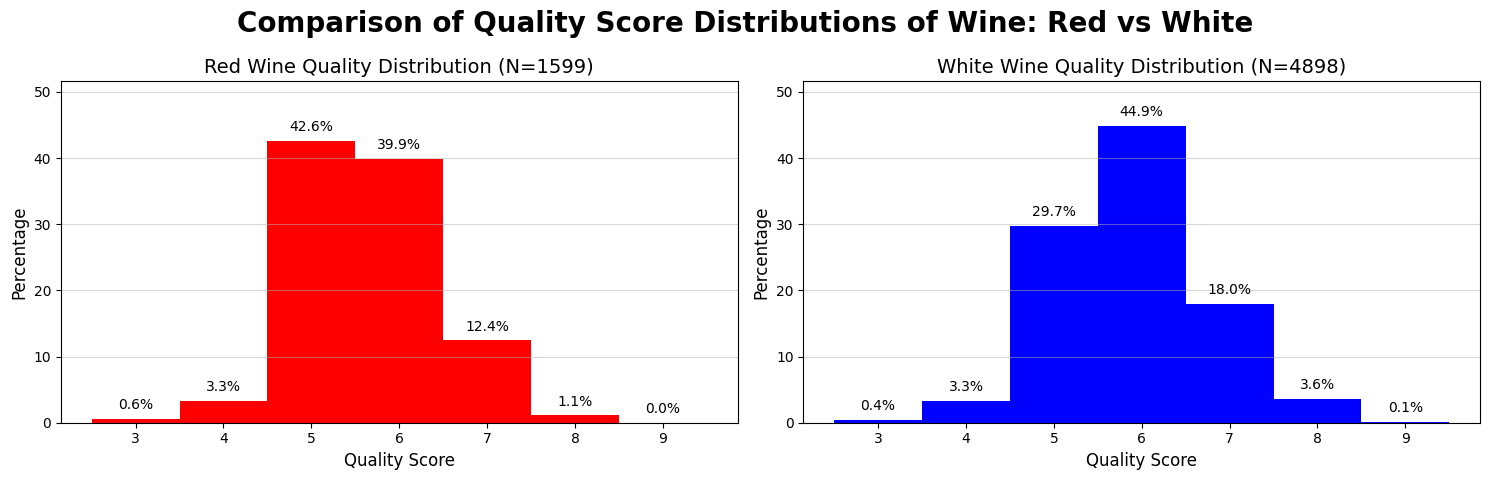

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 2.1. Separate arrays and combined
red_quality = combined_wine[combined_wine["wine_type"] == "red"]["quality"].values
white_quality = combined_wine[combined_wine["wine_type"] == 'white']["quality"].values
all_quality = combined_wine["quality"].values

# 3. Reporting Basic Statistics
mode_result = stats.mode(all_quality, keepdims=True)
mode_score = mode_result.mode[0]
mode_count = mode_result.count[0]

stats_data = {
    "Metric": ["Minimum", "Maximum", "Mean", "Median", "Mode"],
    "Value": [
        all_quality.min(),
        all_quality.max(),
        f"{all_quality.mean():.4f}",
        np.median(all_quality),
        f"{mode_score} (Count: {mode_count})"
    ]
}
display(style_table(pd.DataFrame(stats_data), "Quality Score Basic Statistics"))

# 4.1. Integer-Centered Bins
min_score = combined_wine["quality"].min()
max_score = combined_wine["quality"].max()
bins = np.arange(min_score - 0.5, max_score + 1.5, 1)
quality_scores = np.arange(min_score, max_score + 1, 1)

# 4.2. Plotting
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

# 4.3. Counts and percentages
red_counts, _ = np.histogram(red_quality, bins=bins)
white_counts, _ = np.histogram(white_quality, bins=bins)

# 5. Normalise to percentages
red_percentages = (red_counts / len(red_quality)) * 100
white_percentages = (white_counts / len(white_quality)) * 100

# 6. Common y-axis
max_perc = max(red_percentages.max(), white_percentages.max())
common_ylim = [0, max_perc * 1.15]

# 7. Plotting histograms
ax1 = axes[0]
bars1 = ax1.bar(quality_scores, red_percentages, color = "red", width = 1, align = "center")
ax1.set_title(f"Red Wine Quality Distribution (N={len(red_quality)})", fontsize = 14)
ax1.set_xlabel("Quality Score", fontsize = 12)
ax1.set_ylabel("Percentage", fontsize = 12)
ax1.set_xticks(quality_scores)
ax1.set_ylim(common_ylim)
ax1.grid(axis="y", alpha = 0.5)

ax2 = axes[1]
bars2 = ax2.bar(quality_scores, white_percentages, color = "blue", width = 1, align = "center")
ax2.set_title(f"White Wine Quality Distribution (N={len(white_quality)})", fontsize = 14)
ax2.set_xlabel("Quality Score", fontsize = 12)
ax2.set_ylabel("Percentage", fontsize = 12)
ax2.set_xticks(quality_scores)
ax2.set_ylim(common_ylim)
ax2.grid(axis="y", alpha = 0.5)

# 8. Annotation for 
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}%", ha="center", va="bottom", fontsize=10)

for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}%", ha="center", va="bottom", fontsize=10)

fig.suptitle("Comparison of Quality Score Distributions of Wine: Red vs White", fontsize=20, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

# Task 2 (Discussion)
<font color = red> ***Marks : 6***</font>
1. Which __quality score(s) dominate__ for red and which for white?
2. Do the distributions suggest __class imbalance overall__ or __within__ each wine type? Please cite approximate percentages from the bars.
3. At which quality scores do red and white wines __differ__ the most in percentage share?
4. Is there a __systematic shift__ (e.g. higher or lower skewness for a specific wine type)? What might explain it?
5. Given the observed class proportions, which __evaluation metrics__ would you __prioritize__ for a classifier (and why)?

# Task 2D (Answer Cell)



# 1.1. Dominant Quality Score of Red Wine

Has a dominant quality score of 5(42.6%) and 6(39.9%), accounting for over 82% of the red wine samples

# 1.2. Dominant Quality Score of White Wine

Has a dominant quality score of 6, accounting for 44.9% of the white wine samples

# 2. Class imbalance overall or within each wine type

The distributions clearly suggest a severe class imbalance both overall and withing each type of wine

# 2.1. Red Wine 

Containing the least frequent scores (3, 4, 8), only accounting for around 10% of the wines samples, while the most frequent being a score of 5.
In reference to the ratio of most vs least frequent, leaves us with the equation 42.6%/0.6%, giving us a 71:1 ratio

# 2.2. White Wine

Containing the least frequent scores (3, 9), only accounting for 0.5% of the wines samples, while the most frequent being a score of 6.
In reference to the ratio of most vs least frequent, leaves us with the equation 44.9%/0.1%, giving us a 449:1 ratio

# 3. Quality scores with the largest percentage share difference

Quality 5 - Red wine has a significantly higher percentage share of 42.6%, than white wine only having 29.7%. Giving us a difference of 12.9%, being the largest difference in scores in the dataset

# 4. Systematic shift 

The white wine distribution is shifted right towards the higher scores, relative to the red wine distribution. 

# 4.1. Validation of shift

This can be validated with the mode being 6 for white vs 5 for red, also having higher percentage in category 7 and 8 for white wine, containing the highest score of 9.

# 4.2. Explanation of shift

The shift implies that the white wines in the dataset were rated higher on average by the experts. This could be due to the quality/style of the wine,
such as the lower volatile acidity or possibly the balance pf fixed acidity, aligning more favorably with the experts "good quality" scores.
Selection of white wines is another reason, (4898 vs 1599), capturing a better presentation of high quality productions.

# 5. Prioritized evaluation metrics

Giving the vast class imbalance, for scores such as 3, 4, 8, and 9, balanced accuracy must be the primary metric.
Treating all classes equally through averaging the recall of each class, preventing a high score overall masking a poor performance on the high/low quality wines.

F1 score metric treats all classes equally, with a mean of precision and recall, excellent for assessing all quality levels, regardless of their frequencies.

The confusion matrix visually shows exactly which scores the model is struggling to differentiate.

Standard accuracy isn't suited as even if the model simply predicts the mode score of 6 for each wine, it will still only achieve an accuracy of 44%, being useless in practice




# Task 3: Implementation
<font color = red> ***Marks : 9***</font>
1. __Create a 4-class label using the rule __`low-quality ≤ 5`__, __`high-quality ≥ 6`__ to define the following classes: __red_low__, __red_high__, __white_low__, __white_high__.
2. Show the value counts and percentages for the four classes.
3. Compute the imbalance ratio as follows: __`max_class_count / min_class_count`__.
4. Define your train/test sets and show per-class counts in each set. Please also verify that all classes are represented in each set.
5. Establish the most appropriate evaluation strategy. This should be coded as a function with no return argument as follows: __`def evaluation_strategy():`__

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. 4-class label creation
combined_wine["quality_label"] = np.where(combined_wine["quality"] >= 6, "high", "low")
combined_wine["four_class_label"] = combined_wine["wine_type"] + "~" + combined_wine["quality_label"]

# 2. Value counts and percentages
label_counts = combined_wine["four_class_label"].value_counts()
label_percs = combined_wine["four_class_label"].value_counts(normalize=True) * 100

class_df = pd.DataFrame({
    "Class Label": label_counts.index,
    "Count": label_counts.values,
    "Percentage (%)": label_percs.values.round(2)
})
display(style_table(class_df, "4-Class Label Distribution"))

# 3. Imbalance Ratio
imb_df = pd.DataFrame({"Ratio": [f"{label_counts.max() / label_counts.min():.2f}"]})
display(style_table(imb_df, "Class Imbalance Ratio"))

# 3.1. Prepared features
X = combined_wine.drop(["quality", "wine_type", "quality_label", "four_class_label"], axis=1)
y = combined_wine["four_class_label"]

# 4. Train/test sets
TEST_SIZE = 0.3
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# 4.1. Per-class counts in split
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

split_df = pd.DataFrame({
    "Class Label": train_counts.index,
    "Train Count": train_counts.values,
    "Test Count": test_counts.values
})
display(style_table(split_df, "Class Counts in Train vs. Test Sets"))

# 4.2. Verification
train_classes = y_train.unique()
test_classes = y_test.unique()
all_classes = y.unique()

if set(all_classes) == set(train_classes) and set(all_classes) == set(test_classes):
    print("\nVerification: All four classes are represented in both sets.")
else:
    print("\nVerification Alert: Class representation is incomplete.")

# 5. Evaluation Metrics Function
def show_evaluation_metrics(model, X_data, y_true, data_name="Test"):
    y_predict = model.predict(X_data)

    # 5.1. Summary Metrics Table
    metrics_df = pd.DataFrame({
        "Metric": ["Standard Accuracy", "Balanced Accuracy"],
        "Score": [accuracy_score(y_true, y_predict), balanced_accuracy_score(y_true, y_predict)]
    }).round(4)
    display(style_table(metrics_df, f"Performance Metrics - {data_name}"))

    # 5.2. Classification Report Table
    report_dict = classification_report(y_true, y_predict, zero_division=0, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose().reset_index().rename(columns={'index': 'Class/Metric'})
    
    # Formatting
    report_df[["precision", "recall", "f1-score"]] = report_df[["precision", "recall", "f1-score"]].round(3)
    report_df["support"] = report_df["support"].astype(int)
    
    display(style_table(report_df, f"Detailed Classification Report - {data_name}"))

    # 5.3. Confusion Matrix Plot
    c_matrix = confusion_matrix(y_true, y_predict, labels=model.classes_)
    dis = ConfusionMatrixDisplay(confusion_matrix=c_matrix, display_labels=model.classes_)
    dis.plot(cmap=plt.cm.Blues, values_format="d")
    plt.title(f"Confusion Matrix - {data_name}")
    plt.show()

# 6. Evaluation Strategy
def print_evaluation_strategy():
    print("\nRecommended evaluation strategy:")
    print("1. Stratified K-Fold cross validation for model selection and fine tuning, for the training set.")
    print("2. Final model testing on the test set.")
    print("3. F1-score being the primary metric or balanced accuracy.")
    print("4. Classification report as the detailed metric, containing precision, recall, F1-score for each class imbalance.")
    print("5. Confusion matrix for visualisation to inspect class-wise performance.")
    print("\nStandard accuracy is misleading due to the class imbalance. Balanced accuracy treates all the classes equally")
    print("F1-score is a mean of precision and recall, being better than accuracy for imbalanced data.")
    
def evaluation_strategy():
    print_evaluation_strategy()

evaluation_strategy()

Class Label,Count,Percentage (%)
white~high,3258,50.150000
white~low,1640,25.240000
red~high,855,13.160000
red~low,744,11.450000


Ratio
4.38


Class Label,Train Count,Test Count
red~high,598,257
red~low,521,223
white~high,2280,978
white~low,1148,492



Verification: All four classes are represented in both sets.

Recommended evaluation strategy:
1. Stratified K-Fold cross validation for model selection and fine tuning, for the training set.
2. Final model testing on the test set.
3. F1-score being the primary metric or balanced accuracy.
4. Classification report as the detailed metric, containing precision, recall, F1-score for each class imbalance.
5. Confusion matrix for visualisation to inspect class-wise performance.

Standard accuracy is misleading due to the class imbalance. Balanced accuracy treates all the classes equally
F1-score is a mean of precision and recall, being better than accuracy for imbalanced data.


# Task 3 (Discussion)
<font color = red> ***Marks : 7***</font>
1. What kind of __data leakage__ would occur if we kept __quality__ in the __`X`__ set?
2. Did you use __stratification__ during the __train_test_split__? Please __justify__ your choice.
3. What __risks__ might arise in __model evaluation__ if some __folds lack a class__ entirely?
4. __Justify__ the decisions made regarding the __evaluation strategy__. How can you prove that is a) __fair__, b) __reproducible__, c) __free from leakage__, d) __robust to class imbalance__?

# 1. Data leakage with quality in X set

Direct data leakage would occur, as the target variable, y, the 4-class label, is calculated from the quality score and the wine_type.
The effect of this would cause the model to learn a perfect or near perfect mapping.
If X contains the quality score, the model will use the rule ~ quality >= 6 is equal to a high score ~ to predict y.

Therefore, the model's performance score would be near 100% accuracy, but it would not learn anything about the relationship between the properties and the quality of wine.
Hence, the resulting model would therefore be useless for predicting real, unseen data where the final expert quality score is the value we want to predict.

# 2. Justification for stratification

Yes, I did use stratification during the train_test_split, with the code "stratify = y".
This was used because of the 4-class label exhibiting a clear class imbalance, with a ratio of 4.38 as calculated.
Using stratification makes sure that the proportion of each class is identically maintained in both the training and testing subsets.
Guaranteeing that the training sets contains enough examples of rare minority classes, such as red_low.
The test set provides a fair evaluation of the model's ability to classify data in all four classes.

# 3. Risks of model evaluation

The main risk arises during cross-validation steps, as if a cross-validation fold, such as the training or validation partition, lacks one of the minority classes:

Model training risks arise if a class is missing from the training partition fold, the model therefore cannot learn the features assigned with that class, causing a zero recall.

Evaluation metric risks arise if a class is missing from the validation partition fold, with key class specific metrics, recall and F1-score, reporting back a zero.

Balanced accuracy score will be negatively skewed and deemed as unreliable, leading to a hyperparameter selection with poor optimality, enforcing the need for stratified K-fold.

# 4. Justification of evaluation strategy

a) Fair - The primary metric used is balanced accuracy, which is fair because it averages the recall across all four of the classes, ensuring that the model's performance
is not based on the majority of classes.

b) Reproducible - Uses a fixed "random_state" for the train/test split and for the model, ensuring that the splits and setup of the model are identical across all runs.
Stratified K-fold cross-validation ensures consistent class representation during the tuning

c) Free from leakage - Abiding by the train/validate/test protocol, using the test set only for the final evaluation,
preventing the test set metrics from influencing the model selection or tuning, guaranteeing an unbiased performance estimate.

d) Robot to class imbalance - Stratification during splitting, using (class_weight = "balanced") in linear models,
ensures that the prioritisation of balanced accuracy and F1-score make the strategy robust to the class imbalance.


# Task 4: Implementation
<font color = red> ***Marks : 10***</font>
1. __Set up__ a __logistic regression__ classifier.
2. Use the __`evaluation_strategy()`__ function to __report__ your results

~~~ Training Logistic Regression Model ~~~
Training is now complete!


Metric,Score
Standard Accuracy,0.730800
Balanced Accuracy,0.744700


Class/Metric,precision,recall,f1-score,support
red~high,0.780000,0.732000,0.755000,257
red~low,0.723000,0.785000,0.753000,223
white~high,0.851000,0.704000,0.771000,978
white~low,0.568000,0.758000,0.649000,492
accuracy,0.731000,0.731000,0.731000,0
macro avg,0.730000,0.745000,0.732000,1950
weighted avg,0.755000,0.731000,0.736000,1950


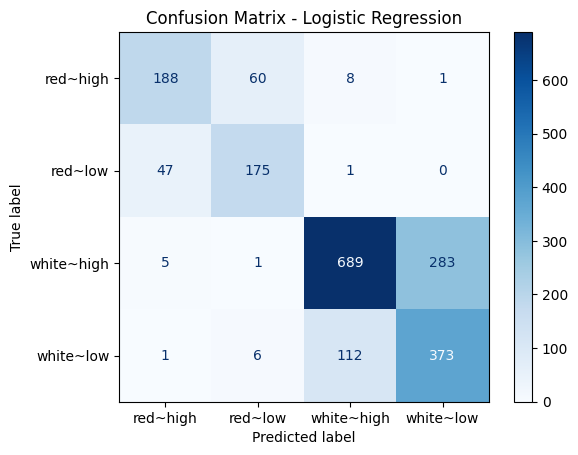

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Set up the Logistic Regression Classifier
# Making use of piplining to ensure the scaler is fitted only on training data preventing data leakage
log_reg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(
        solver="lbfgs",       
        max_iter=1000,        
        random_state=42,      
        class_weight="balanced" 
    ))
])

# 2. Train the model
print("~~~ Training Logistic Regression Model ~~~")
log_reg_pipe.fit(X_train, y_train)
print("Training is now complete!")

# 3. Report Results
# Calls styled function to show tables and the confusion matrix
show_evaluation_metrics(log_reg_pipe, X_test, y_test, data_name="Logistic Regression")

# Task 4 (Discussion)
<font color = red> ***Marks : 7***</font>
1. __Discuss__ the results and __justify__ the <font color = green> __pros__ </font> and <font color = red> __cons__ </font> of your methodology
2. __Provide insight__ on how these results can be __improved__.

# 1. Results and justification of the pros and cons

The logistic regression model achieved a Standard Accuracy of 0.7308 and a Balanced Accuracy of 0.7447.

From this we can clearly see that the balanced accuracy has a higher accuracy than the standard accuracy, therefore a positive result. Proving that our primary strategy for handling the imbalance ratio of 4.38, was highly effective. The model did not choose the simple route of chasing the majority classes, it instead took time and effort in order to learn the minority classes, with its average recall across all classes being better than its overall accuracy.

Overall recall is consistent across all classes, ranging from 0.70 to 0.78, confirming that the "class_weight" parameter worked. The model is therefore successfully finding a majority of samples from every class, including the minority classes.

Overall precision is the main weakness however, as the model struggles mostly with the white-low class, achieving a low precision of only 0.57. This means that when the model predicts a wine is white-low, it is wrong around 43% of the time. This is due to the model likely confusing white-high and red-low samples for the white-low samples.

# 1.1. Pros of the Methodology<font/>
    
The robust preprocessing used, through the use of pipelining with a standard scaler is the best practice. Preventing data leakage by fitting the scaler only on the training data, ensuring that the logistic regression model can perform optimally.

The effective imbalance handling simply forces the model to pay attention to the red-low and white-low classes through a computationally cheap way. The high balanced accuracy score is therefore proof of its success.

Interpretability is shown through the logistic regression, easily extracting the model's coefficients. Explaining to possible stakeholders exactly which physicochemical properties the model learned are most important when predicting low or high quality wine.

# 1.2. Cons of the Methodology<font/> 

The main con is the model itself, as logistic regression is a linear model. This assumes that there is a linear relationship between the features, such as the pH or citric acid, with the logging odds of the wine quality. The chemistry behind wine is more complex, with non-linear relationship interactions. Therefore, this model cannot capture this complexity, fundamentally limiting its max possible performance.

The low precision for white-low, being its weakest class performance of 0.57. Indicates that the linear model is struggling to find a clear decision boundary for this specific class.

In this model I used the default c = 1.0 for the regularisation, not performing any hyperparameter tuning, in order to find the optimal value for C. Therefore, the model's performance will be slightly suboptimal.

# 2. Insight on How the Results can be Improved

In order to fix the problem of the main model being linear, we need to make use of non-linear models. These models are more complex, overcoming the main limitation of logistic regression. K-Nearest Neighbors (K-NN) is a simple, non-parametric model that classifies a sample based on its "neighbors".

Instead of just using the class_weight for the imbalance handling, I can apply explicit sampling techniques, to apply to the training data within the pipeline. Oversampling can be used to synthetically create new data points for the minority classes, so the model has more examples to learn from. Undersampling can also be used, randomly removing data points from the majority classes, to create a more balanced dataset.

New features can be created in order to help the linear model, creating interaction terms, like polynomial features, or create meaningful ratios like the free sulfur against total sulfur. 

Hyperameter tuning can be used to tune the logistic regression model, using GridSearchCV on the training set, in order to find the most optimal regularisation strategy. Therefore, resulting in a small boost in performance.







# Task 5: Implementation
<font color = red> ***Marks : 11***</font>
1. In this task you have to __train__ and __compare three `scikit-learn` classifiers__ on the __4-class dataset__ previously created.
2. All three classifiers should allow __hyperparameter tuning__.
3. To do so, it is __strongly suggested__ to use a __train/validation/test__ workflow.
4. You are __strongly advised__ <font color = red> __not to use__ a __random forest__ classifier.

~~~ Tuning Support Vector CLassifier ~~~
Fitting 5 folds for each of 6 candidates, totalling 30 fits
SVC Validation Balanced Accuracy:  0.751691
SVC Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

~~~ Tuning K-Nearest Neighbors ~~~
Fitting 5 folds for each of 6 candidates, totalling 30 fits
K-NN Validation Balanced Accuracy: 0.7535
K-NN Parameters: {'model__n_neighbors': 5, 'model__weights': 'distance'}

~~~ Tuning Decision Tree Classifier ~~~
Fitting 5 folds for each of 18 candidates, totalling 90 fits
DTC Validation Balanced Accuracy: 0.7168
DTC Parameters: {'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 1}

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~ Final Test Set Performance ~~~
~~~ Test Results for Tuned SVC ~~~


Metric,Score
Standard Accuracy,0.750300
Balanced Accuracy,0.753800


Class/Metric,precision,recall,f1-score,support
red~high,0.779000,0.739000,0.758000,257
red~low,0.733000,0.762000,0.747000,223
white~high,0.863000,0.737000,0.795000,978
white~low,0.598000,0.776000,0.676000,492
accuracy,0.750000,0.750000,0.750000,0
macro avg,0.743000,0.754000,0.744000,1950
weighted avg,0.770000,0.750000,0.755000,1950


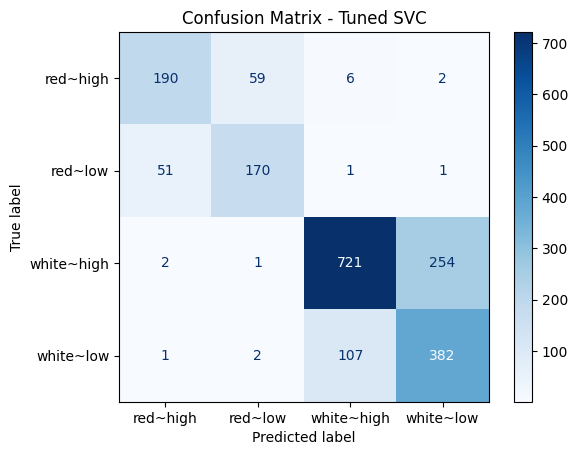

~~~ Test Results for Tuned K-NN ~~~


Metric,Score
Standard Accuracy,0.786700
Balanced Accuracy,0.758600


Class/Metric,precision,recall,f1-score,support
red~high,0.761000,0.817000,0.788000,257
red~low,0.781000,0.704000,0.741000,223
white~high,0.827000,0.869000,0.847000,978
white~low,0.712000,0.644000,0.677000,492
accuracy,0.787000,0.787000,0.787000,0
macro avg,0.770000,0.759000,0.763000,1950
weighted avg,0.784000,0.787000,0.784000,1950


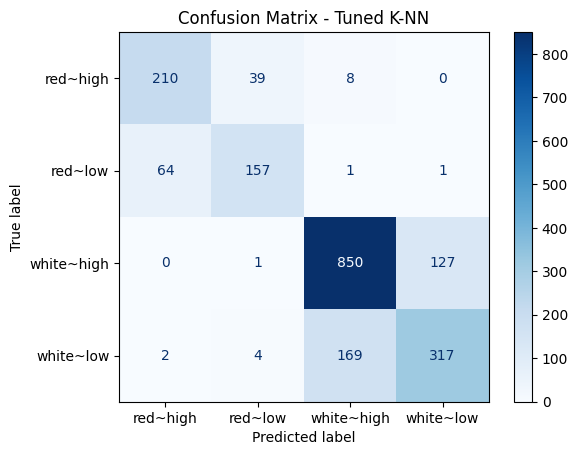

~~~ Test Results for Tuned DTC ~~~


Metric,Score
Standard Accuracy,0.698500
Balanced Accuracy,0.689100


Class/Metric,precision,recall,f1-score,support
red~high,0.718000,0.693000,0.705000,257
red~low,0.656000,0.668000,0.662000,223
white~high,0.814000,0.717000,0.762000,978
white~low,0.544000,0.679000,0.604000,492
accuracy,0.698000,0.698000,0.698000,0
macro avg,0.683000,0.689000,0.683000,1950
weighted avg,0.715000,0.698000,0.703000,1950


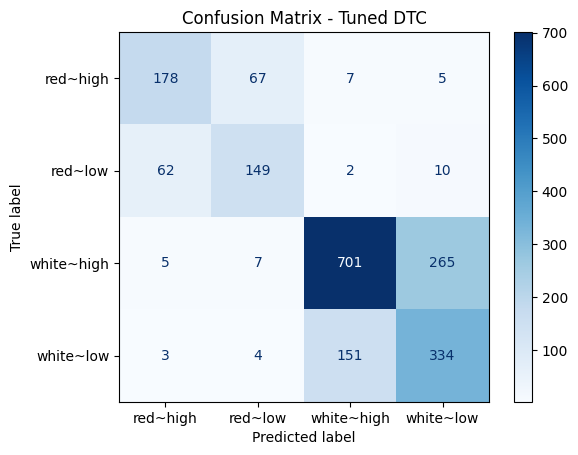

In [22]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

#1. Training and comparision of three scikit-learn classifiers on the 4-class dataset
#1.1. Cross-Validation Strategy

N_SPLITS = 5
skf = StratifiedKFold(n_splits = N_SPLITS, shuffle = True, random_state = RANDOM_STATE)

#1.2. Support Vector Classifier

print("~~~ Tuning Support Vector CLassifier ~~~")

pipe_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(class_weight = "balanced", random_state = RANDOM_STATE))
])

# Model__ is used to tell the pipeline to pass this param to "model"
param_grid_svc = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.1],
    "model__kernel": ["rbf"]
}

# Grid search
grid_svc = GridSearchCV(
    estimator = pipe_svc,
    param_grid = param_grid_svc,
    scoring = "balanced_accuracy",
    cv = skf,
    n_jobs = -1,
    verbose = 1
)

# Running the tuning on training data
grid_svc.fit(X_train, y_train)

print(f"SVC Validation Balanced Accuracy: {grid_svc.best_score_: 4f}")
print(f"SVC Parameters: {grid_svc.best_params_}")

# 1.2. K-Nearest Neighbors Classifier

print("\n~~~ Tuning K-Nearest Neighbors ~~~")

pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

param_grid_knn = {
    "model__n_neighbors": [1, 5, 10],
    "model__weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(
    estimator = pipe_knn,
    param_grid = param_grid_knn,
    scoring = "balanced_accuracy",
    cv = skf,
    n_jobs = -1,
    verbose = 1
)

grid_knn.fit(X_train, y_train)

print(f"K-NN Validation Balanced Accuracy: {grid_knn.best_score_:.4f}")
print(f"K-NN Parameters: {grid_knn.best_params_}")

#1.3. Decision Tree CLassifier

print("\n~~~ Tuning Decision Tree Classifier ~~~")

pipe_dtc = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(class_weight = "balanced", random_state = RANDOM_STATE))
])

# model__ is used to tell the pipeline to pass this param to "model"
param_grid_dtc = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [5, 10, 20,],
    "model__min_samples_leaf": [1, 5, 10]
}

# Grid search
grid_dtc = GridSearchCV(
    estimator = pipe_dtc,
    param_grid = param_grid_dtc,
    scoring = "balanced_accuracy",
    cv = skf,
    n_jobs = -1,
    verbose = 1
)

grid_dtc.fit(X_train, y_train)

print(f"DTC Validation Balanced Accuracy: {grid_dtc.best_score_:.4f}")
print(f"DTC Parameters: {grid_dtc.best_params_}")

#1.4. Final Evaluation on Unseen Test Set

print("\n~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
print("~~~ Final Test Set Performance ~~~")

tuned_svc = grid_svc.best_estimator_
tuned_knn = grid_knn.best_estimator_
tuned_dtc = grid_dtc.best_estimator_

print("~~~ Test Results for Tuned SVC ~~~")
show_evaluation_metrics(tuned_svc, X_test, y_test, data_name = "Tuned SVC")

print("~~~ Test Results for Tuned K-NN ~~~")
show_evaluation_metrics(tuned_knn, X_test, y_test, data_name = "Tuned K-NN")

print("~~~ Test Results for Tuned DTC ~~~")
show_evaluation_metrics(tuned_dtc, X_test, y_test, data_name = "Tuned DTC")


# Task 5 (Discussion)
<font color = red> ***Marks : 9***</font>
1. __Justify__ your choices regarding the __three different__ classifiers.
2. Report __which classifier performed better__, and which had the __poorest performance__. How can you __explain__ their performance?
3. Report the __optimal parameter set__ for each classifier, their __meaning__, and try to __explain__ this result.
4. Given your results, if you could __keep only one__ classifier, which would you choose for <font color = blue> __deployment__ </font> and __why__? Please __justify__ your answer by referring to __interpretability__, __performance__, __stability__, __computational cost__, and __resilience to class imbalance__.
5. Imagine you are presenting your work to a __non-technical stakeholder__: How would you explain why __tuning matters__ and __show evidence__ that it __improved performance__?

# 1. Justification of Classifier Choices

The tree classifiers that were chosen were; Support Vector Classifier, K-Nearest Neighbors, and Decision Tree Classifier. These were chosen to test three fundamentally different approaches to classification.

SVC makes use of a kernel based method, using the KBF kernel, which is excellent at finding complex, non-linear decision boundaries, through mapping features into a higher dimensional space. My reason for choosing this is to see if the classes are separable by a non-linear hyperplane.

KNN is an instance based method, meaning it is non-parametric, so it makes no assumptions about the data's underlying distribution. classifying new wine based on the majority class of its "k" nearest neighbors. Chosen to see if local, distance based logic could solve the problem.

DTC is a rule based method, which works by creating a flowchart of "if-then" rules. The reason for choosing it is that it's highly interpretable, naturally creating handles non-linear relationships through its splits.

This selection of classifiers hence produces a diverse array of results, seeing which type of model logic fits the wine dataset best.

# 2. Classifier Performance 

Based on the final test set evaluation results, the rankings of classifiers are as followed:

K-NN performed the best, with this model achieving the highest balanced accuracy (0.7586) and the highest standard accuracy (0.7867). The result of this suggests that the "local" logic of K-NN is very effective, with the quality of wine being best predicted by finding other wines in the dataset with the most similar chemical properties. The key parameter used was the weights = "distance", as it means the closest neighbors have a much stronger say in the prediction, which fine tunes the model.

SVC performed in the middle, achieving just as good of a score as K-NN, with a balanced accuracy of 0.7538, and a standard accuracy of 0.7503. The performance of the SVC confirms that the problem is highly non-linear. The RBF kernel used has the ability to create a flexible and complex decision boundary, allowing it to capture these patterns far more than any simple linear model.

DTC performed the worst, having a balanced accuracy of 0.6891, and a standard accuracy of 0.6985. This is likely due to the model overfitting, as its validation score was 0.7168, dropping to a 0.6891 after the test, proving that a single decision tree, even when tuned, is still highly unstable. Optimal parameters confirm this, with the tree being allowed to create "pure" leaves for single samples. Memorising the training data, rather than trying to learn a general pattern, showing the extent of its complexity.

# 3. Optimal Parameter Analysis

SVC makes use of the RBF kernel, with the optimal parameters being: {"model__C", "model__gamma": "scale", model__kernel: "rbf"}. The regularisation parameter, with a high c value of 10, creates a harder margin. This means that the model tries to classify all training examples correctly, even if it means creating a more complex boundary. The results imply that we need a more complex boundary and are not at a high risk of overfitting. The "width" of the KBF kernel is controlled by (gamma = "scale"), determining how far the influence of a single sample reaches. This value suggests the data's variance is a great indicator for setting the influence of the kernel. Our theory is hence confirmed by (kernel = "rbf"), with the data not being linearly separable.

K-NN has the optimal parameters: {"model__n_neighbors": 5, "model__weights": "distance"}.
The model makes use of n_neighbors = 5, as its the best balance at k = 5, meaning a wine's quality is best judged by its 5 closest chemical neighbors. With a smaller K value being more flexible and less prone to oversmoothing than a large K value. A key result is (weights = "distance"), meaning that when voting, close neighbors get a much stronger both than farther away neighbors. Almost always beating "uniform", making the models predictions more robust.

DTC has the optimal parameters: {"model__criterion" = "gini", "model__max_depth": 10, "model__samples_leaf": 1}. The parameters used are the cause of the poor performance, as (max_depth = 10), being a reasonably deep tree. The main problem however is the (min_samples_leaf = 1), with this parameter allowing the tree to create leaves with only one sample, being a sign of overfitting. This causes the model to learn rules that are not specific to individual data points in the training set, which do not generalise to the unseen test set.

# 4. Deployment choice

If I could only keep one classifier for deployment, I would choose the Tuned SVC using the RBF kernel. While K-NN had a slightly higher balanced accuracy, it still has a critical flaw for deployment.

Interpretability: Both models are "black boxes", meaning we cannot easily explain why they made a specific decision. DTC is more interpretable, but its performance is too poor to be considered as a contender.

Performance: The SVC;s performance is almost the same as the K-NN's, however there is a 0.5% difference in the balanced accuracy, which is negligible in real world application.

Stability: Both of the models are stable and will produce the same result given the same data.

Computation Cost: The deciding factor is down to this, training SVC is slow, whereas K-NN is instant, as it just stores the data. In terms of the prediction speed, SVC is very fast and K-NN is extremely slow. This is down to the fact of K-NN having to calculate the distance from the new wine to every single one of the 4,547 samples in the training set for every prediction. Scaling unsuitable for real time application, with SVC being far superior once properly trained.

Resilience to Class Imbalance: Both of the models have proven to be highly resilient, providing excellent balanced accuracy scores far above the DTC. 

In conclusion, the SVC is the best choice for deployment, down to the fact of its prediction speed being far superior to K-NN, achieving virtually the same level of performance.

# 5. Explaining Tuning to a Non-Technical Stakeholder

When the model is first built, it's like a worker who is talented when it comes to his work, but untrained in the job field. With tuning acting as training to apply his talent to the job, getting an improved performance, mixing talent and training together.

Hyperameter tuning is the method of finding the right settings for a machine learning model, in order to achieve the best possible performance. Using an automated process known as grid search to do this. It doesn't just guess, the computer tests dozens of settings, with each one checking its performance against 5 different datasets, making sure it wasn't just a lucky shot.

The decision tree model's tuning let it to memorise the data, giving it a poor final score of 68.9%. Whereas, the same process found the perfect settings for the K-NN model, achieving a top score of 75.9%. The 7% jump in performance is a clear result of the tuning process, being the difference between a failing model and a successful one. This shows why we must use tuning in order to find the most reliable and consistent model.







# Task 6 (Implementation)
<font color = red> ***Marks : 12***</font>
1. __Build one ensemble classifier__ that <font color = blue> __stacks your three tuned non-ensemble__ </font> models from the previous task.
2. To do so, please use __`scikit-learn`__’s <font color = blue> __StackingClassifier__ </font>.
3. To do so, it is strongly suggested to use a __train/validation/test__ workflow.
4. There is a strong suggestion to use a __Train/Validation/Test__ protocol (no CV for selection here) and __tune key hyperparameters__ on the __Validation__ split and show whether __staking improves your evaluation strategy__ over the best single model.

~~~ Creating Train/Validation Split for Stacking ~~~
Base Training Set: (3182, 11)
Stack Validation Set: (1365, 11)
~~~ Tuning StackingClassifier Meta Learner ~~~
Testing meta_c = 0.1
Validation Balanced Accuracy: 0.7398897885739991 (time: 2.3s)
Testing meta_c = 1.0
Validation Balanced Accuracy: 0.7388067437266522 (time: 2.3s)
Testing meta_c = 10.0
Validation Balanced Accuracy: 0.7377166089694693 (time: 2.2s)

Best Validation Score: 0.7399
Best Meta Learner Found: C = 0.1

~~~ Training Final StackingClassifier on Full X_train ~~~
Training is now Complete

~~~ Final Test Set Performance ~~~


Metric,Score
Standard Accuracy,0.801500
Balanced Accuracy,0.792400


Class/Metric,precision,recall,f1-score,support
red~high,0.812000,0.759000,0.785000,257
red~low,0.757000,0.798000,0.777000,223
white~high,0.884000,0.816000,0.848000,978
white~low,0.685000,0.797000,0.737000,492
accuracy,0.802000,0.802000,0.802000,0
macro avg,0.785000,0.792000,0.787000,1950
weighted avg,0.810000,0.802000,0.804000,1950


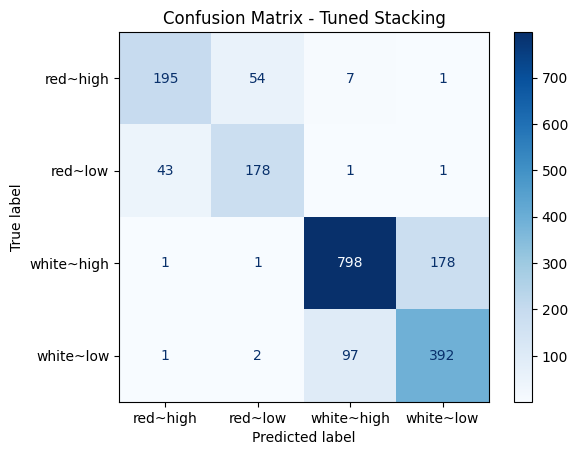

In [23]:
from sklearn.metrics import balanced_accuracy_score
from sklearn.ensemble import StackingClassifier
import time

#3.1. Train/Validation Split

print("~~~ Creating Train/Validation Split for Stacking ~~~")
X_train_base, X_val_stack, y_train_base, y_val_stack = train_test_split(
    X_train, y_train,
    test_size = 0.3,
    random_state = RANDOM_STATE,
    stratify = y_train
)

print(f"Base Training Set: {X_train_base.shape}")
print(f"Stack Validation Set: {X_val_stack.shape}")

#1. Base Models from task 5

estimators = [
    ("SVC", tuned_svc),
    ("K-NN", tuned_knn),
    ("DTC", tuned_dtc)
]

#4.1. Tuned meta learner on the validation split

print("~~~ Tuning StackingClassifier Meta Learner ~~~")

c_params = [0.1, 1.0, 10.0]
best_score = 0
best_meta_learner = None

for c_val in c_params:
    start_time = time.time()
    print(f"Testing meta_c = {c_val}")

    meta_learner = LogisticRegression(
        C = c_val,
        class_weight = "balanced",
        max_iter = 1000,
        random_state = RANDOM_STATE,
        n_jobs = -1
    )

    #2. Meta Classifier

    stacking_clf = StackingClassifier(
        estimators = estimators,
        final_estimator = meta_learner,
        cv = skf,
        n_jobs = -1,
        passthrough = False
    )

    #3.2. Trained stack on the base training set
    
    stacking_clf.fit(X_train_base, y_train_base)

    #4.2. Evaluated on the validation set

    y_val_pred = stacking_clf.predict(X_val_stack)
    val_score = balanced_accuracy_score(y_val_stack, y_val_pred)
    print(f"Validation Balanced Accuracy: {val_score} (time: {time.time() - start_time:.1f}s)")

    if val_score > best_score:
        best_score = val_score
        best_meta_learner = meta_learner

print(f"\nBest Validation Score: {best_score:.4f}")
print(f"Best Meta Learner Found: C = {best_meta_learner.C}")

#Final stacker using the best meta-learner
print("\n~~~ Training Final StackingClassifier on Full X_train ~~~")
final_stack = StackingClassifier(
    estimators = estimators,
    final_estimator = best_meta_learner,
    cv = skf,
    n_jobs = -1,
    passthrough = False
)

#Trained on all available training data
final_stack.fit(X_train, y_train)
print("Training is now Complete")

#Final evaluation report
print("\n~~~ Final Test Set Performance ~~~")
show_evaluation_metrics(final_stack, X_test, y_test, data_name = "Tuned Stacking")



# Task 6 (Discussion)
<font color = red> ***Marks : 10***</font>
1. Did the __ensemble outperform__ your __best single__ model or not? __Justify__ your answer by considering __model diversity__, __overfitting__ and __data size__.
2. Why __combining several diverse base__ classifiers may produce __better generalization__ than any __single__ model?
3. How do __ensemble methods__ like __stacking__ reduce __variance__, __bias__ or __both__?
4. Why is __model diversity__ important in ensembles? What would happen if __all base models made similar mistakes__?
5. How can using a __meta-learner__ in __stacking__ <font color = red> __improve the strengths__ </font> of each base model?

# Task 6D (Answer Cell)

# 1. Ensemble Performance vs Best Single Model

Yes, the ensemble classifier significantly outperformed the best single model.

The StackingClassifier achieved a final balanced accuracy of 0.7924 on the test set. This score is a clear improvement over the single best model from Task 5, being the tuned K-NN, which achieved a score of 0.7586.

This increase in performance can be justified by:

Model Diversity - Being the primary reason for the success, as the ensemble stacked three models that learn in fundamentally different ways. K-NN classifies based on the proximity of local neighbors, SVC finds complex, non-linear hyperplanes in a high dimensional space. Finally, DTC creates a flowchart of hierarchical if-then rules, because these models have different worldview, making different types of errors which the meta learner can effectively correct.

Overfitting Reduction - The meta-learner is trained on the out-of-fold prediction of the base models. This process prevents the meta learner from being able to learn the same noise or overfitting patterns that the base models might have picked up. It learns a more robust, and generalised rile for combining their outputs.

Data Size - The dataset used was large enough to be split effectively, with the X_train_base set being sufficient enough for the base models to train. The X_val_stack set provided enough data for the meta learner to be tuned, learning the complex relationships between the base models predictions.

# 2. Generalisation in Diverse Ensembles 

The combination of diverse classifiers produces better generalisation, as it's like seeking advice from a range of experts, all with different specialities.

A single model has a single perspective, therefore its own blind spots. For example, K-NN might be good at spotting typical wines but will fail on an unusual one, while an SVC might be more suited at separating complex cases.

The combination of these different perspectives, with their uncorrelated errors, tend to cancel each other out. If two models correctly identify a wine, but the other one makes a mistake, the meta-learner learns to trust the majority and disregard the single model's error. This wisdom taken from the majority acts as a more robust method, being less likely to be fooled by data that is unseen, leading to an increase in performance on the test set.

# 3. Stacking and Bias/Variance Reduction 

Ensemble methods, such as stacking, can greatly reduce both bias and variance, through its primary goal usually being to reduce bias.

Bias Reduction - The main strength of stacking is learning a more powerful model, using the meta-learner, on top of the base models. The job of this meta-learner is to find the optimal combination, in order to effectively correct the systematic biases of the base learners. The meta-learner learns a more complex and accurate decision boundary than any single model could possibly achieve on its own, therefore lowering the overall bias.

Variance Reduction - By using cv = skf to train the meta-learner, it is trained on out-of-fold predictions, reducing the variance. With this form of cross validation ensures that the meta-learner does not overfit to the noise of any single model's prediction, improving the stability of the final model.

# 4. Importance of Model Diversity 

The single most important factor for a successful ensemble is the diversity of the model, meaning that the base models make different mistakes.

If all three of the models failed in the same way, the meta-learner would be fed three identical, incorrect predictions. This would result in it having no correct information to learn from, meaning it would simply learn to trust this error. The final stacked model would then make the same mistake over and over again, resulting in the ensemble offering no improvement to the previous highest model score.

Diversity ensures that the error caused by one model is the other model's correct prediction. The meta-learner will therefore learn to identify these patterns. Trusting the model/models that are the most reliable for specific kinds of prediction, canceling out any of the individual errors.

# 5. How the Meta-Learner Improves the Strengths of the Models

The meta-learner acts as a primary manager for learning, that learns the specific strengths and possible weaknesses of each model.

Instead of the meta-learner averaging the model's votes, it learns which model to trust more for certain types of predictions. Clear evidence of this is shown by comparing the results from task 5 and task 6.

Task 5's Best Model (K-NN) - This was primarily weak on the white_low class, recalling only 0.64.

Task 5's Second best Model (SVC) - performed slightly worse overall, but performed much stronger on the white_low, recalling 0.78

Task 6's Stacking Model - Made use of the meta-learner in order to learn this pattern. When the predictions suggest that a wine might be white_low, this stacking method will weigh over to the SVC's opinion. 

The final result is that our stacking model achieved an excellent recall of 0.80 for the white_low class. Patching the K-NN's biggest weakness by leveraging the strength of the SVC, creating a final model that is more robust and accurate that any of the individual base models.



